# InvestIQ — Stock Direction Baseline (XGBoost)

**Goal:** predict whether a stock's close price will be higher **20 trading days** from now (binary classification), using `stock_prices` and `financial_statements` from the InvestIQ MySQL DB.

**Scope of this stage:** a working, leakage-free baseline on the currently available (small) dataset. No LSTM/Transformers.

Pipeline code lives in `ml/stock_model/`:

| Module | Responsibility |
|---|---|
| `config.py` | horizon, feature windows, reporting lags, split fractions, XGBoost params |
| `data.py` | load + clean + validate prices and financials |
| `features.py` | price features, point-in-time fundamentals, target |
| `modeling.py` | purged time split, training, metrics, feature importance, saving |

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Make `ml/` importable when the notebook runs from ml/notebooks/
ML_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ML_DIR))

from stock_model import config, data, features, modeling

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

# Chart styling
BLUE = "#2a78d6"
TEXT_SECONDARY = "#52514e"
GRID = "#e4e3df"
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": GRID,
    "axes.labelcolor": TEXT_SECONDARY,
    "xtick.color": TEXT_SECONDARY,
    "ytick.color": TEXT_SECONDARY,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.6,
})

## 1. Inspect the database

In [2]:
engine = data.get_engine()
data.table_overview(engine)

,table_name,n_rows,n_companies,min_date,max_date
0,stock_prices,248,1,2025-09-02,2026-09-01
1,financial_statements,89,11,2021-03-31,2026-06-30


## 2. Load, clean and validate prices

Cleaning checks: duplicate `(company_id, date)` rows, missing/non-positive closes, inconsistent OHLC bars (low > open/close or high < open/close), zero volume (treated as missing), and unusual calendar gaps.

In [3]:
raw_prices = data.load_prices(engine)
prices, price_report = data.clean_prices(raw_prices)

print(price_report)
print("Companies with prices:", prices["symbol"].unique().tolist())
prices.describe().T

{'rows_in': 248, 'duplicates_dropped': 0, 'missing_close_dropped': 0, 'non_positive_close_dropped': 0, 'inconsistent_ohlc_dropped': 0, 'zero_volume_set_nan': 0, 'rows_out': 248}
Companies with prices: ['RELIANCE']


,count,mean,min,25%,50%,75%,max,std
company_id,248.0,1844.0,1844.0,1844.0,1844.0,1844.0,1844.0,0.0
price_date,248,2026-03-03 03:23:13.548387072,2025-09-02 00:00:00,2025-12-01 18:00:00,2026-02-28 12:00:00,2026-06-04 06:00:00,2026-09-01 00:00:00,NaN
open_price,248.0,1398.68871,1258.0,1325.925,1382.8,1459.7,1593.0,85.982362
high_price,248.0,1410.418145,1274.2,1333.975,1395.55,1473.075,1611.8,85.743076
low_price,248.0,1386.47621,1249.8,1312.25,1372.55,1444.625,1578.2,86.018365
close_price,248.0,1397.770565,1258.8,1324.725,1383.15,1458.05,1592.3,85.81411
volume,248.0,13663465.447581,2066169.0,8653577.75,11876297.0,17422434.25,42634247.0,6843353.075724


In [4]:
# Calendar gaps longer than a long weekend / holiday break
data.price_gap_report(prices)

,company_id,symbol,price_date,gap_days


## 3. Load and validate financial statements

In [5]:
company_ids = prices["company_id"].unique().tolist()
financials = data.clean_financials(data.load_financials(engine, company_ids))

display(financials[["company_id", "period_type", "period_end_date", "revenue", "operating_profit",
                    "net_profit", "eps", "total_assets", "total_debt", "total_equity",
                    "operating_cash_flow"]])

# Share of non-null values per column: shows which ratios are computable today
data.financial_coverage(financials)

,company_id,period_type,period_end_date,revenue,operating_profit,net_profit,eps,total_assets,total_debt,total_equity,operating_cash_flow
0,1844,quarterly,2025-09-30,259105.0,29124.0,22146.0,NaN,NaN,NaN,NaN,NaN
1,1844,quarterly,2025-12-31,269819.0,29697.0,22167.0,NaN,NaN,NaN,NaN,NaN
2,1844,quarterly,2026-03-31,298506.0,27195.0,20616.0,NaN,NaN,NaN,NaN,NaN
3,1844,quarterly,2026-06-30,316018.0,30630.0,23001.0,NaN,NaN,NaN,NaN,NaN
4,1844,yearly,2023-03-31,877835.0,NaN,73670.0,NaN,1607431.0,NaN,828881.0,115032.0
5,1844,yearly,2024-03-31,901064.0,NaN,78633.0,NaN,1755986.0,NaN,925788.0,158788.0
6,1844,yearly,2025-03-31,964693.0,NaN,80787.0,NaN,1950121.0,NaN,1009626.0,178703.0
7,1844,yearly,2026-03-31,1057219.0,NaN,95610.0,NaN,2178140.0,NaN,1085866.0,192113.0


period_type,quarterly,yearly
revenue,1.0,1.0
operating_profit,1.0,0.0
net_profit,1.0,1.0
eps,0.0,0.0
total_assets,0.0,1.0
total_debt,0.0,0.0
total_equity,0.0,1.0
operating_cash_flow,0.0,1.0
investing_cash_flow,0.0,1.0
financing_cash_flow,0.0,1.0


**Data gaps found:**
- `eps` and `total_debt` are NULL for every row → EPS, EPS growth, debt/equity and P/E can't be computed yet (the feature code handles them automatically once they are populated).
- There is no share count, so market cap / P/B / P/S are unavailable.
- ROCE needs EBIT + capital employed (debt), so it is omitted; ROE and ROA are computed from yearly rows.

**Point-in-time rule:** statements are only visible to the model from `period_end_date + lag` (45 days for quarterly, 60 days for yearly, per SEBI LODR deadlines). They are joined with `merge_asof(direction="backward")`.

## 4. Build features and target

In [6]:
dataset, feature_cols, empty_features = features.build_dataset(prices, financials)

print(f"Dataset: {dataset.shape[0]} rows, {len(feature_cols)} usable features")
print("Dropped (no data in DB):", empty_features)
print(f"Target: {features.TARGET_COL} = 1 if {features.FORWARD_RETURN_COL} > 0")
print("Class balance (share up):", round(dataset[features.TARGET_COL].mean(), 3))

dataset[feature_cols].notna().mean().round(2).rename("non_null_share").to_frame().T

Dataset: 208 rows, 28 usable features
Dropped (no data in DB): ['q_revenue_yoy', 'q_net_profit_yoy', 'q_eps', 'q_eps_qoq', 'y_debt_to_equity', 'y_eps', 'y_eps_growth', 'pe_ratio']
Target: target = 1 if fwd_return_20d > 0
Class balance (share up): 0.442


,ret_1d,ret_5d,ret_20d,close_to_sma_5,close_to_sma_20,close_to_sma_50,sma_5_to_sma_20,volatility_5d,volatility_20d,volume_change_1d,volume_to_avg_5d,volume_to_avg_20d,high_low_range,close_to_open,rsi_14,q_revenue_qoq,q_net_profit_qoq,q_operating_profit_qoq,q_operating_margin,q_net_margin,y_revenue_growth,y_net_profit_growth,y_total_assets_growth,y_net_margin,y_roe,y_roa,y_equity_to_assets,y_ocf_to_net_profit
non_null_share,1.0,1.0,1.0,1.0,1.0,0.86,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.55,0.55,0.55,0.86,0.86,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [7]:
dataset[["price_date", "close_price"] + feature_cols[:8] + [features.FORWARD_RETURN_COL, features.TARGET_COL]].tail()

,price_date,close_price,ret_1d,ret_5d,ret_20d,close_to_sma_5,close_to_sma_20,close_to_sma_50,sma_5_to_sma_20,volatility_5d,fwd_return_20d,target
203,2026-07-29,1275.9,0.006468,-0.009856,-0.024541,0.000894,-0.014715,-0.023752,-0.015595,0.008666,0.017321,1
204,2026-07-30,1292.9,0.013324,0.016271,-0.008132,0.010947,-0.001178,-0.010293,-0.011994,0.008393,-0.008276,0
205,2026-07-31,1307.8,0.011524,0.023318,0.002914,0.017854,0.010184,0.001909,-0.007535,0.009201,-0.015905,0
206,2026-08-03,1319.0,0.008564,0.030469,-0.001741,0.020377,0.018926,0.010963,-0.001421,0.009146,-0.031842,0
207,2026-08-04,1290.9,-0.021304,0.018301,-0.013375,-0.004933,-0.002106,-0.009609,0.002841,0.014233,0.014021,1


### Leakage check

If any feature used future data, recomputing features on a price history truncated at some cutoff would change their values before that cutoff. They must be identical.

In [8]:
cutoff = dataset["price_date"].quantile(0.7)
truncated, _, _ = features.build_dataset(prices[prices["price_date"] <= cutoff], financials)

check = dataset.merge(truncated, on=["company_id", "price_date"], suffixes=("", "_trunc"))
max_diff = max(
    (check[c] - check[f"{c}_trunc"]).abs().max()
    for c in feature_cols
    if f"{c}_trunc" in check
)

print(f"Rows compared: {len(check)}, max feature difference: {max_diff}")
assert max_diff == 0 or np.isnan(max_diff), "Feature leakage detected"

Rows compared: 125, max feature difference: 0.0


## 5. Time-based train / validation / test split

Chronological split on dates (60% / 20% / 20%), with **20-date purge gaps** between splits: a training label looks 20 days ahead, so without the gap the last training labels would be computed from validation-period prices.

In [9]:
train, val, test = modeling.time_split(dataset)
splits = {"train": train, "val": val, "test": test}

modeling.describe_splits(splits)

,rows,start,end,pct_up
split,,,,
train,100,2025-09-30,2026-02-23,0.530
val,33,2026-03-25,2026-05-15,0.424
test,35,2026-06-16,2026-08-04,0.486


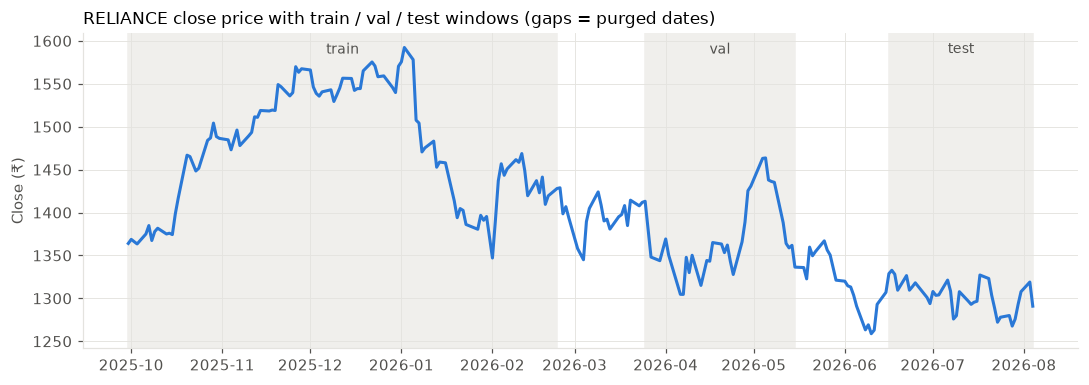

In [10]:
fig, ax = plt.subplots(figsize=(10, 3.6))
ax.plot(dataset["price_date"], dataset["close_price"], color=BLUE, linewidth=2)

for name, part in splits.items():
    start, end = part["price_date"].min(), part["price_date"].max()
    ax.axvspan(start, end, color="#f0efec", zorder=0)
    ax.text(start + (end - start) / 2, 0.97, name, transform=ax.get_xaxis_transform(),
            ha="center", va="top", color=TEXT_SECONDARY, fontsize=9)

symbol = dataset["symbol"].iloc[0]
ax.set_title(f"{symbol} close price with train / val / test windows (gaps = purged dates)",
             loc="left", fontsize=11)
ax.set_ylabel("Close (₹)")
plt.tight_layout()
plt.show()

## 6. Train baseline XGBoost

In [11]:
X_train, y_train = train[feature_cols], train[features.TARGET_COL]
X_val, y_val = val[feature_cols], val[features.TARGET_COL]

model = modeling.train_xgb(X_train, y_train, X_val, y_val)

print("Best iteration (early stopping on validation logloss):", model.best_iteration)

Best iteration (early stopping on validation logloss): 9


## 7. Evaluate

Metrics for every split, plus an **always-predict-up** baseline. A model that can't beat it isn't useful.

In [12]:
metrics = modeling.evaluate_splits(model, splits, feature_cols)
metrics.round(3)

,accuracy,precision,recall,f1,roc_auc,n,pct_up_actual,pct_up_predicted
xgb_train,0.930,0.897,0.981,0.937,0.979,100.0,0.530,0.580
xgb_val,0.636,0.667,0.286,0.400,0.466,33.0,0.424,0.182
xgb_test,0.514,0.000,0.000,0.000,0.623,35.0,0.486,0.000
always_up_val,0.424,0.424,1.000,0.596,0.500,33.0,0.424,1.000
always_up_test,0.486,0.486,1.000,0.654,0.500,35.0,0.486,1.000


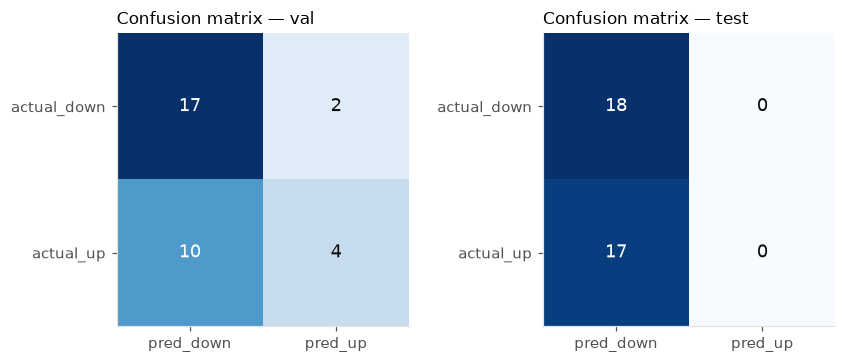

,pred_down,pred_up
actual_down,18,0
actual_up,17,0


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.4))

for ax, name in zip(axes, ["val", "test"]):
    cm = modeling.confusion_frame(model, splits[name], feature_cols)
    ax.imshow(cm.values, cmap="Blues", vmin=0)
    ax.grid(False)
    ax.set_xticks([0, 1], cm.columns)
    ax.set_yticks([0, 1], cm.index)
    ax.set_title(f"Confusion matrix — {name}", loc="left", fontsize=11)

    for i in range(2):
        for j in range(2):
            value = cm.values[i, j]
            ax.text(j, i, value, ha="center", va="center", fontsize=12,
                    color="white" if value > cm.values.max() / 2 else "#0b0b0b")

plt.tight_layout()
plt.show()

modeling.confusion_frame(model, test, feature_cols)

## 8. Feature importance

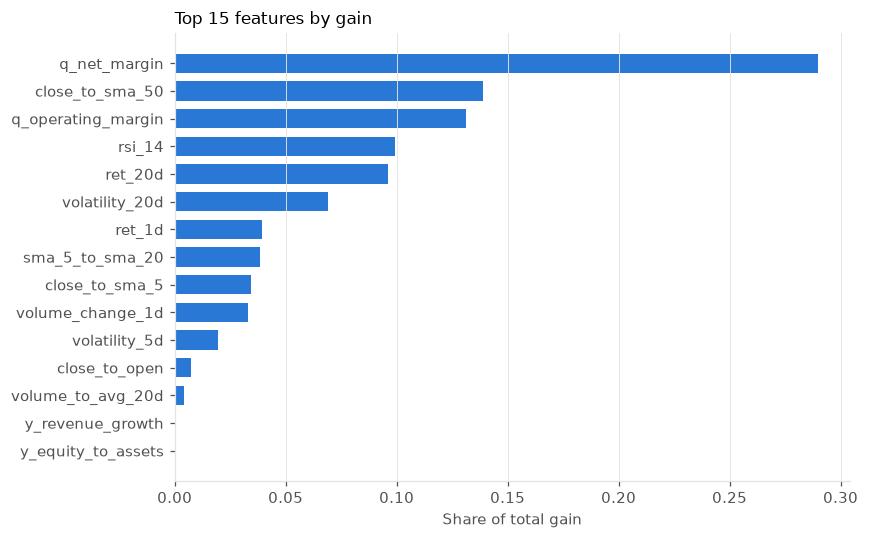

,feature,gain,n_splits,gain_share
0,q_net_margin,21.654690,1,0.289739
1,close_to_sma_50,10.388139,59,0.138993
2,q_operating_margin,9.815301,5,0.131328
3,rsi_14,7.408340,1,0.099123
4,ret_20d,7.165560,4,0.095875
5,volatility_20d,5.175865,3,0.069253
6,ret_1d,2.923656,4,0.039118
7,sma_5_to_sma_20,2.868114,1,0.038375
8,close_to_sma_5,2.561885,6,0.034278
9,volume_change_1d,2.471346,1,0.033067


In [14]:
importance = modeling.feature_importance(model, feature_cols)

top = importance.head(15).iloc[::-1]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top["feature"], top["gain_share"], color=BLUE, height=0.7)
ax.grid(axis="y", visible=False)
ax.set_xlabel("Share of total gain")
ax.set_title("Top 15 features by gain", loc="left", fontsize=11)
plt.tight_layout()
plt.show()

importance

**Reading the importance:** `gain` is the average loss reduction when a feature is used for a split, while `n_splits` counts how often it is used. A fundamental feature with high gain but very few splits (e.g. a quarterly margin) usually acts as a **period marker** here: with a single stock, its value only changes about once a quarter, so it effectively tells the model *when* a row is. That's a warning sign, not a real signal.

## 9. Save the baseline model

In [15]:
model_path, meta_path = modeling.save_model(model, feature_cols, metrics)
print(model_path)
print(meta_path)

/Users/amit/Desktop/InvestIQ/ml/models/stock_direction_xgb_baseline.json
/Users/amit/Desktop/InvestIQ/ml/models/stock_direction_xgb_baseline_meta.json


## 10. Findings and next steps

**Caveat: this is a pipeline baseline, not a trustworthy model yet.**
- `stock_prices` currently holds **one stock (RELIANCE) with ~1 year of data**, which leaves a couple of hundred labelled rows and only a few dozen test rows. Metrics on a test set this small swing wildly, and the classes are skewed differently in each split.
- Overlapping 20-day labels mean neighbouring rows are highly correlated, so the *effective* sample size is much smaller than the row count.
- Train metrics far above validation/test metrics indicate overfitting, which is expected with this little data.

**Next steps, in priority order:**
1. **Dataset size:** ingest multi-year prices for many stocks (e.g. NIFTY 100/500). The pipeline already handles multiple companies (grouping by `company_id`, splitting by date).
2. **Fundamentals:** populate `eps`, `total_debt`, shares outstanding and interest/EBIT in `financial_statements`. EPS growth, debt/equity and P/E then turn on automatically; add ROCE, P/B and P/S.
3. **Cross-sectional features:** returns relative to NIFTY / sector, and cross-sectional ranks of features per date.
4. **Target:** try excess return vs index, a dead-zone target (ignore |return| < x%), or 5D/60D horizons.
5. **Validation:** walk-forward (expanding window) CV instead of a single split; tune hyperparameters and the decision threshold on validation only.